In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Titanic-Dataset.csv")
df.shape



(891, 12)

In [18]:
df.head(30)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
#df.Survived.describe()
survival_rate = df['Survived'].mean()
survival_count = df['Survived'].value_counts()

print(str(survival_count) + "    " + str(survival_rate))


Survived
0    549
1    342
Name: count, dtype: int64    0.3838383838383838


In [22]:
df.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

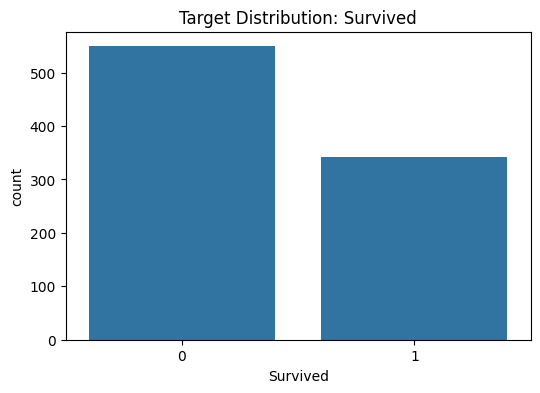

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Target Distribution: Survived")
plt.show()

In [24]:
eda_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "num_unique": df.nunique(),
    "num_missing": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100
})

eda_summary.sort_values("num_unique")

,dtype,num_unique,num_missing,missing_pct
Survived,int64,2,0,0.000000
Sex,str,2,0,0.000000
Pclass,int64,3,0,0.000000
Embarked,str,3,2,0.224467
Parch,int64,7,0,0.000000
SibSp,int64,7,0,0.000000
Age,float64,88,177,19.865320
Cabin,str,147,687,77.104377
Fare,float64,248,0,0.000000
Ticket,str,681,0,0.000000


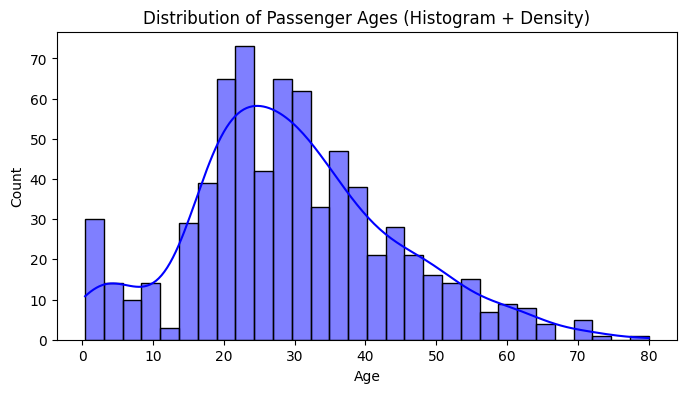

In [25]:
plt.figure(figsize=(8, 4))
# 'kde=True' adds the smooth density line on top of the histogram
sns.histplot(data=df, x='Age', bins=30, kde=True, color='blue')
plt.title('Distribution of Passenger Ages (Histogram + Density)')
plt.show()


C:\Users\siste\AppData\Local\Temp\ipykernel_9564\3712207611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Survived', y='Age', palette='muted')


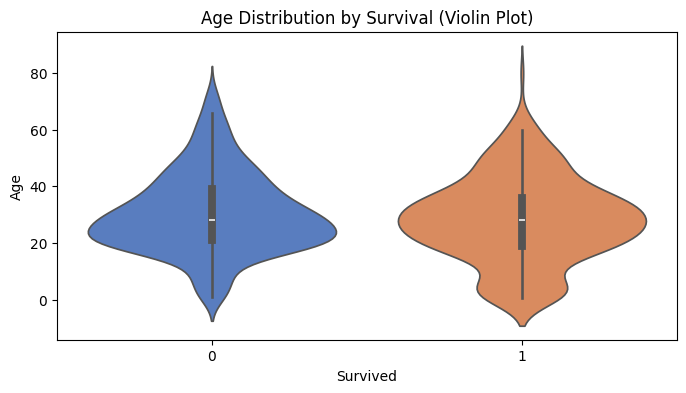

In [26]:
plt.figure(figsize=(8, 4))
# x is categorical (Survived), y is continuous (Age)
sns.violinplot(data=df, x='Survived', y='Age', palette='muted')
plt.title('Age Distribution by Survival (Violin Plot)')
plt.show()


C:\Users\siste\AppData\Local\Temp\ipykernel_9564\2358649572.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', palette='Set2')


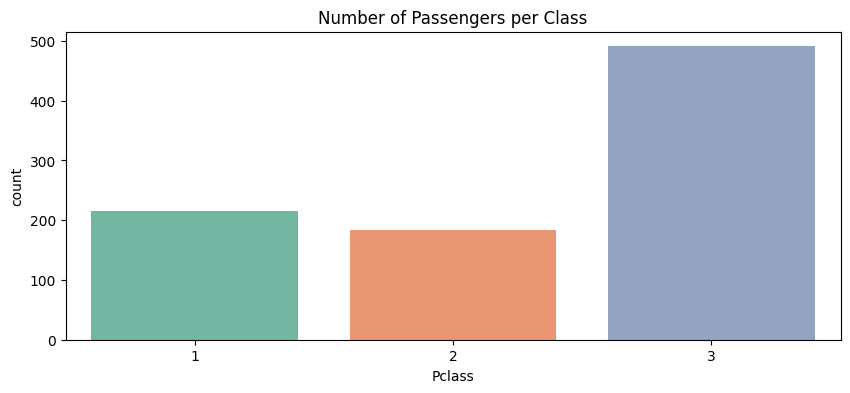

In [27]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Pclass', palette='Set2')
plt.title('Number of Passengers per Class')
plt.show()


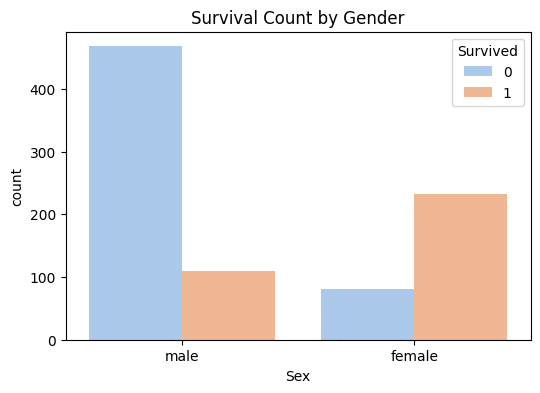

In [28]:
plt.figure(figsize=(6, 4))
# 'hue' splits the count by survival status!
sns.countplot(data=df, x='Sex', hue='Survived', palette='pastel')
plt.title('Survival Count by Gender')
plt.show()


C:\Users\siste\AppData\Local\Temp\ipykernel_9564\3715659452.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Sex', y='Survived', palette='pastel', errorbar=None)


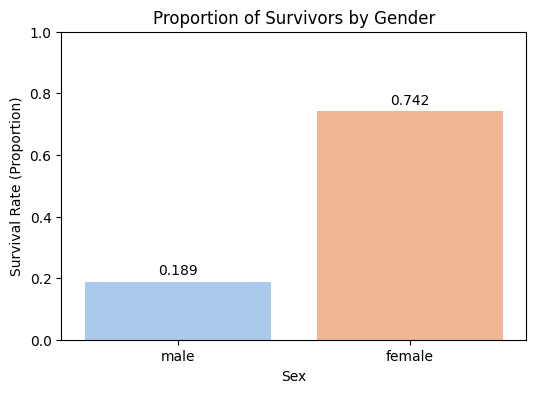

In [29]:
plt.figure(figsize=(6, 4))

# We need to save the plot to a variable (usually called 'ax' for axis)
ax = sns.barplot(data=df, x='Sex', y='Survived', palette='pastel', errorbar=None) 
# Note: I added errorbar=None to remove the little black confidence lines so the numbers look cleaner

# This is the magic line that adds the values on top of the bars
for container in ax.containers:
    # fmt='%.2f' rounds the number to 2 decimal places (e.g., 0.74 instead of 0.742038)
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.title('Proportion of Survivors by Gender')
plt.ylabel('Survival Rate (Proportion)')
plt.ylim(0, 1) # Keep the scale 0 to 1

plt.show()


C:\Users\siste\AppData\Local\Temp\ipykernel_9564\665863181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set1')


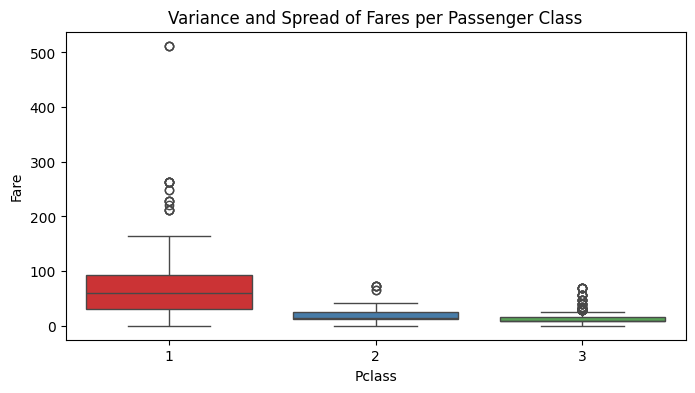

In [30]:
plt.figure(figsize=(8, 4))
# Looking at Ticket Fare split by Class
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set1')
plt.title('Variance and Spread of Fares per Passenger Class')
plt.show()


In [31]:
# Gives you count, mean, std (standard deviation/variance), min, 25%, 50%, 75%, and max
df['Fare'].describe()


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

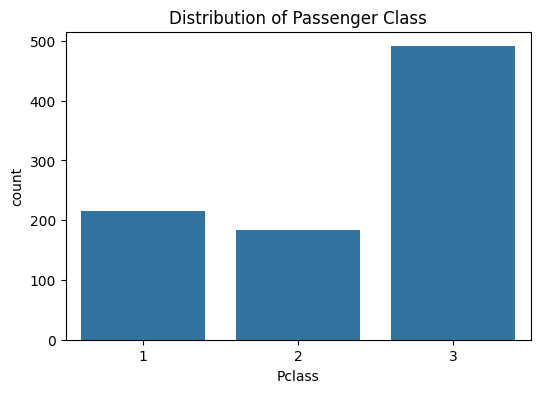

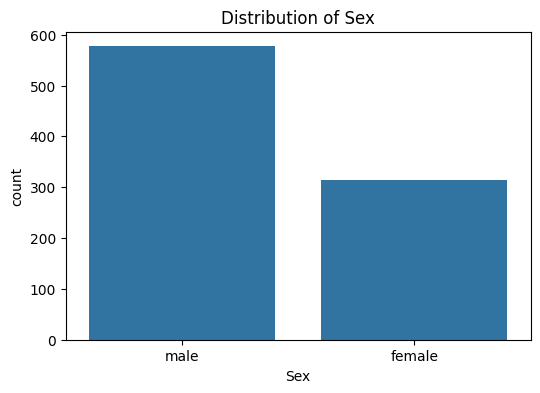

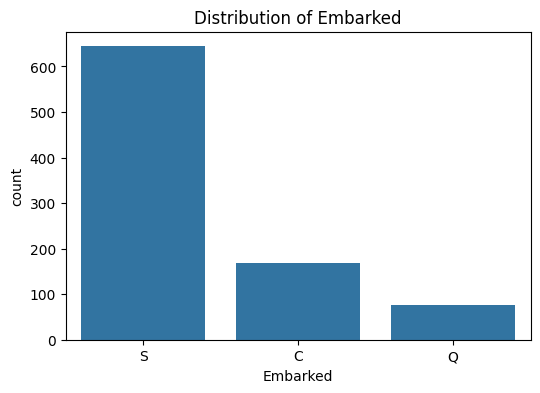

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass")
plt.title("Distribution of Passenger Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex")
plt.title("Distribution of Sex")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Embarked")
plt.title("Distribution of Embarked")
plt.show()